In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import scipy.optimize as opt
import os
import pickle

# set the font size
plt.rcParams.update({'font.size': 7})
# set Helvetica globally
plt.rcParams['font.family'] = 'Helvetica'

cell_lines_subset = ["HEK293T", "HeLa", "SKNSH", "MCF7", "HUH7", "A549"]
cell_lines_rest = ["HaCaT", "JEG3", "Tera1", "PC3"]
cell_lines_measured = cell_lines_subset + cell_lines_rest
    
def find_outliers(diff_df, threshold=0.3):
    diff_df = abs(diff_df)
    diff_df = diff_df[diff_df > threshold]
    return diff_df.index

In [2]:
data_dir_input = "../measured_data/2_normalized_log10"

# get the name of all files in "reference" folder
reference_files = os.listdir(data_dir_input)

# read them into a dictionary
reference_dict = {}
for reference_file in reference_files:
    if reference_file.endswith(".csv"):
        reference_dict[reference_file.split('.')[0]] = pd.read_csv(os.path.join(data_dir_input, reference_file), index_col=0)

In [3]:
# get only the high confidence microRNAs in mirbase
mirbase = pd.read_csv("../microrna_data/mirbase_extended.csv", index_col=0)
mirbase_high_confidence = mirbase[mirbase["confidence"] == "high"]

In [4]:
df_alles = pd.read_csv("../microrna_data/2_output/Alles2019_conormalized.csv", index_col=0)
df_alles = np.log10(df_alles)

df_keller = pd.read_csv('../microrna_data/2_output/Keller2023_conormalized.csv', index_col=0)
df_keller = np.log10(df_keller)

df_lorenzi = pd.read_csv('../microrna_data/2_output/Lorenzi2019_conormalized.csv', index_col=0)
df_lorenzi = np.log10(df_lorenzi)

df_new = pd.read_excel('../microrna_data/250917_new_data/250917_new_data_human.xlsx', index_col=0)

In [5]:
# get likely real mirnas
with open("../microrna_data/likely_real_mirnas.pkl", "rb") as f:
    likely_real_mirnas = pickle.load(f)

In [6]:
def get_common_index(series1, series2):
    series1_index = series1.dropna().index
    series2_index = series2.dropna().index
    common_index = series1_index.intersection(series2_index)
    series1 = series1.loc[common_index]
    series2 = series2.loc[common_index]
    return series1, series2

In [7]:
# get all dfs that contain "single" in their key
single_dfs = {key: reference_dict[key].copy() for key in reference_dict.keys() if "single" in key}

for key, df in single_dfs.items():
    df.set_index("miRNA1", inplace=True)
    # remove all columns that are not 3UTR
    df = df.filter(regex='(3UTR)').copy()
    # drop NaN values
    df.dropna(inplace=True)
    single_dfs[key] = df

In [8]:
# high confidence
measured_single = single_dfs["1_mirna_full_single_high_conf"]
measured_single = pd.concat([measured_single, single_dfs["2_mirna_full_single_low_conf_mirgenedb"]], axis=0)
measured_single.columns = [col.split("_")[0] for col in measured_single.columns]

In [9]:
def hill_func_log_regular(x, c1=3, c2=4.5):
    """The expression is assumed to be normalized to one.
    The microRNA data is assumed to be log10.
    The return value is also log10."""
    x = 10**x
    c1 = 10**c1
    c2 = 10**c2
    
    result = (1 / (1 + x / c1)) * (1 + x / c2)
    return np.log10(result)


def fit_hill_function(x_data, y_data):
    # set bounds and initial guesses for non-scale fitting parameters
    p0 = [3, 10]
    num_params = len(p0)
    bounds = ([1, 9.99], [10, 10.01])

    popt, pcov = opt.curve_fit(
        lambda x, *params: hill_func_log_regular(x, *params),
        x_data,
        y_data,
        p0=p0,
        bounds=bounds,
        maxfev=5000
    )
    return popt, pcov

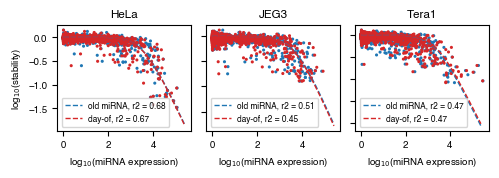

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(5, 1.8))

for i, cell_line in enumerate(["HeLa", "JEG3", "Tera1"]):
    ax = axes[i]
    ax.set_title(f"{cell_line}")

    x_log = np.arange(0, 5.5, 0.1)
    x_lin = 10**x_log

    # old data
    exp_old, knockdown = get_common_index(df_keller[cell_line], measured_single[cell_line])
    popt, _ = fit_hill_function(exp_old, knockdown)
    r = stats.pearsonr(knockdown, hill_func_log_regular(exp_old, *popt))[0]
    ax.scatter(exp_old, knockdown, s=5, color="tab:blue", rasterized=True, edgecolors="none")
    ax.plot(x_log, hill_func_log_regular(x_log, *popt), color="tab:blue", linewidth=1, ls="--", label=f"old miRNA, r2 = {round(r**2, 2)}")

    exp_new, knockdown = get_common_index(df_new[cell_line], measured_single[cell_line])
    popt, _ = fit_hill_function(exp_new, knockdown)
    r = stats.pearsonr(knockdown, hill_func_log_regular(exp_new, *popt))[0]
    ax.scatter(exp_new, knockdown, s=5, color="tab:red", rasterized=True, edgecolors="none")
    ax.plot(x_log, hill_func_log_regular(x_log, *popt), color="tab:red", linewidth=1, ls="--", label=f"day-of, r2 = {round(r**2, 2)}")

    ax.set_xlabel(r"log$_{10}$(miRNA expression)")
    ax.set_ylabel(r"log$_{10}$(stability)")

    ax.legend(fontsize=6)
    ax.label_outer()

plt.tight_layout()
os.makedirs("../plots/20_new_data_comparsion", exist_ok=True)
plt.savefig(os.path.join("../plots/20_new_data_comparsion", "hill_fit_new_data.svg"), dpi=400)